Q1. Create a Python program using a GRU-based model that detects and highlights names of people, places, and organizations in a given text.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, TimeDistributed

sentences = [
    "John works at Google in New York",
    "Elon Musk founded Tesla in California",
    "Microsoft is based in Seattle",
    "Mary visited Paris"
]

labels = [
    ["PER", "O", "O", "ORG", "O", "LOC"],
    ["PER", "PER", "O", "ORG", "O", "LOC"],
    ["ORG", "O", "O", "LOC"],
    ["PER", "O", "LOC"]
]

tokenizer = Tokenizer(lower=True, oov_token="<OOV>")
tokenizer.fit_on_texts(sentences)

X = tokenizer.texts_to_sequences(sentences)

label_map = {"O": 0, "PER": 1, "LOC": 2, "ORG": 3}
y = [[label_map[tag] for tag in seq] for seq in labels]

max_len = max(len(seq) for seq in X)
X = pad_sequences(X, maxlen=max_len, padding='post')
y = pad_sequences(y, maxlen=max_len, padding='post')

y = tf.keras.utils.to_categorical(y, num_classes=4)

model = Sequential([
    Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=64, input_length=max_len),
    GRU(64, return_sequences=True),
    TimeDistributed(Dense(4, activation='softmax'))
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.fit(X, y, epochs=50, verbose=1)

def predict_entities(text):
    seq = tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_len, padding='post')

    pred = model.predict(seq)[0]
    pred_labels = np.argmax(pred, axis=-1)

    inv_label_map = {0: "O", 1: "PER", 2: "LOC", 3: "ORG"}

    words = text.split()

    print("\nEntities Found:")
    for i in range(len(words)):
        if i < len(pred_labels):
            label = inv_label_map[pred_labels[i]]
            if label != "O":
                print(f"{words[i]} → {label}")

predict_entities("Howard Stark work for Hydra in New York")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 0.1786 - loss: 1.4010
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.2500 - loss: 1.3861
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3214 - loss: 1.3717
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6071 - loss: 1.3575
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.6071 - loss: 1.3433
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6071 - loss: 1.3289
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6071 - loss: 1.3141
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6071 - loss: 1.2989
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6071 - loss: 1.2830
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6071 - loss: 1.2664
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6071 - loss: 1.2489
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.6071 - loss: 1.2304
Ep

Q2. Develop a Python program that lets users add new words and translations, simulating an English-to-Spanish dictionary.

In [2]:
# Simple English-to-Spanish Dictionary

dictionary = {}

def add_word():
    english = input("Enter English word: ").lower()
    spanish = input("Enter Spanish translation: ").lower()
    dictionary[english] = spanish
    print(f"Added: {english} → {spanish}")

def search_word():
    english = input("Enter English word to search: ").lower()
    if english in dictionary:
        print(f"{english} → {dictionary[english]}")
    else:
        print("Word not found!")

def show_all():
    if dictionary:
        print("\nDictionary Contents:")
        for eng, spa in dictionary.items():
            print(f"{eng} → {spa}")
    else:
        print("Dictionary is empty.")

# -----------------------------
# Menu-driven program
# -----------------------------
while True:
    print("\n--- English to Spanish Dictionary ---")
    print("1. Add new word")
    print("2. Search word")
    print("3. Show all words")
    print("4. Exit")

    choice = input("Enter choice: ")

    if choice == "1":
        add_word()
    elif choice == "2":
        search_word()
    elif choice == "3":
        show_all()
    elif choice == "4":
        print("Exiting program...")
        break
    else:
        print("Invalid choice, try again.")


--- English to Spanish Dictionary ---
1. Add new word
2. Search word
3. Show all words
4. Exit
Enter choice: 1.
Invalid choice, try again.

--- English to Spanish Dictionary ---
1. Add new word
2. Search word
3. Show all words
4. Exit
Enter choice: 1
Enter English word: Hello
Enter Spanish translation: 4
Added: hello → 4

--- English to Spanish Dictionary ---
1. Add new word
2. Search word
3. Show all words
4. Exit
Enter choice: 1
Enter English word: Hello


KeyboardInterrupt: Interrupted by user

Q3. Visualize the clustered groups using a scatter plot with different colors for each cluster.

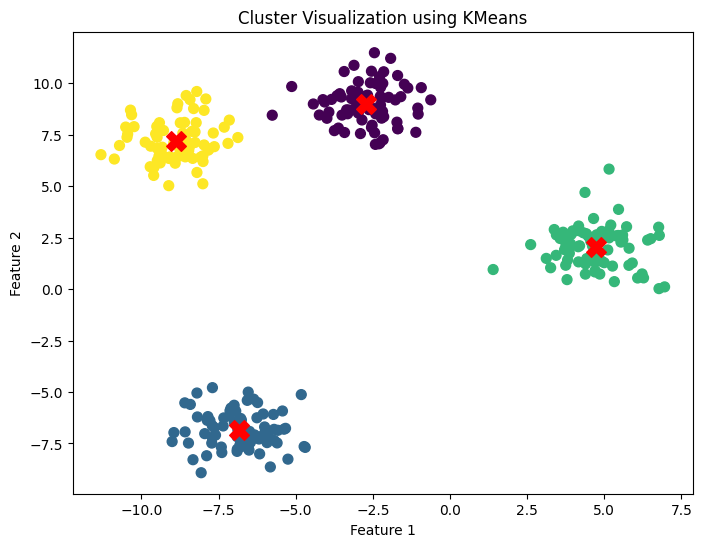

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# -----------------------------
# Step 1: Create sample data
# -----------------------------
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=42)

# -----------------------------
# Step 2: Apply KMeans clustering
# -----------------------------
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)
labels = kmeans.labels_
centers = kmeans.cluster_centers_

# -----------------------------
# Step 3: Visualize clusters
# -----------------------------
plt.figure(figsize=(8, 6))

# Scatter plot for each cluster
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)

# Plot cluster centers
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X')

plt.title("Cluster Visualization using KMeans")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

Q4. Research and decide on the appropriate Microsoft Azure AI service for a vision-related problem, explaining your choice.

Q5. Build a linear regression model in Python that predicts house prices based on features like area and location.

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# -----------------------------
# Sample dataset
# -----------------------------
data = {
    "Area": [1000, 1500, 1800, 2400, 3000, 3500],
    "Location": ["CityA", "CityB", "CityA", "CityC", "CityB", "CityC"],
    "Price": [200000, 250000, 280000, 350000, 400000, 500000]
}

df = pd.DataFrame(data)

# -----------------------------
# Features and target
# -----------------------------
X = df[["Area", "Location"]]
y = df["Price"]

# -----------------------------
# Preprocessing (One-Hot Encoding for Location)
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("loc", OneHotEncoder(), ["Location"])
    ],
    remainder="passthrough"
)

# -----------------------------
# Model Pipeline
# -----------------------------
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -----------------------------
# Train model
# -----------------------------
model.fit(X_train, y_train)

# -----------------------------
# Prediction
# -----------------------------
predictions = model.predict(X_test)

# -----------------------------
# Output results
# -----------------------------
for i in range(len(X_test)):
    print(f"Actual: {y_test.values[i]} | Predicted: {predictions[i]:.2f}")

Actual: 200000 | Predicted: 170909.09
Actual: 250000 | Predicted: 195454.55
